<a href="https://colab.research.google.com/github/seigdev/artificial-intelligence/blob/main/assessments/assignment_one.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip3 install Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.9 MB/s eta 0:00:00


In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_hub as hub
import seaborn as sns
import tldextract
import re
import whois
import numpy as np
from datetime import datetime
from urllib.parse import urlparse
from Levenshtein import distance as levenshtein_distance
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## data collection

In [2]:
def fetch_crypto_datasets(url):
    # Make the request
    response = requests.get(url)
    if response.status_code == 200:
        # Return the JSON data
        return response.json()
    else:
        print(f"Failed to fetch data. Status code: {response.status_code}. Reason: {response.reason}")

        return []

In [3]:
datasets_raw = fetch_crypto_datasets("https://raw.githubusercontent.com/seigdev/artificial-intelligence/refs/heads/main/crypto_data.json")

In [4]:
datasets_df = pd.DataFrame(datasets_raw)

## eda

In [5]:
# view the first few rows
datasets_df.head()

,url,label,label_no
0,https://arbitrum-claim.net,scam,1
1,https://allocate-dym.network,scam,1
2,https://rionegro.com.ar,legit,0
3,https://net-layerzero.com,scam,1
4,https://leugss.top,scam,1


In [6]:
# basic info
print(datasets_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   url       100000 non-null  object
 1   label     100000 non-null  object
 2   label_no  100000 non-null  object
dtypes: object(3)
memory usage: 2.3+ MB
None


In [7]:
# count the number of scam and legitimate links
datasets_df["label"].value_counts()

,count
label,
scam,80000
legit,20000


In [8]:
# Summary statistics for numerical columns (if any)
print(datasets_df.describe())

                                 url   label label_no
count                         100000  100000   100000
unique                         99680       2        2
top     https://app.uniswap.org/swap    scam        1
freq                              22   80000    80000


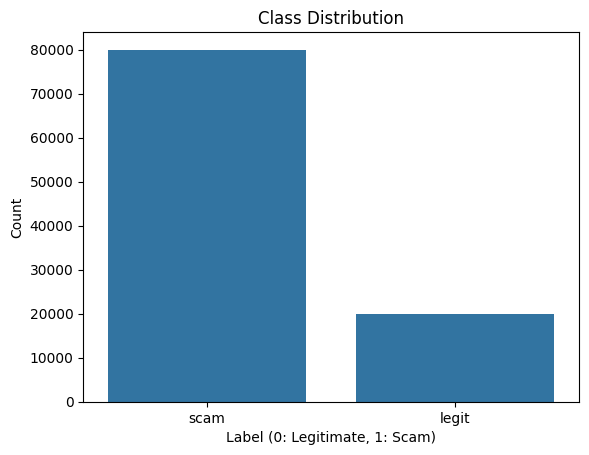

In [9]:
#  count the number of scam and legitimate links
class_distribution = datasets_df["label"].value_counts()

# plot the distribution
sns.barplot(x=class_distribution.index, y=class_distribution.values)
plt.title("Class Distribution")
plt.xlabel("Label (0: Legitimate, 1: Scam)")
plt.ylabel("Count")
plt.show()

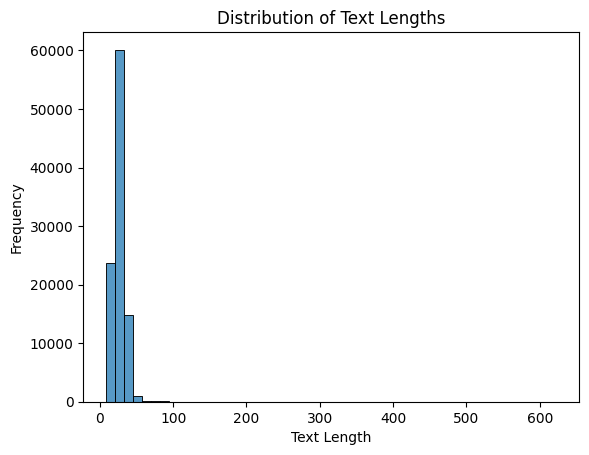

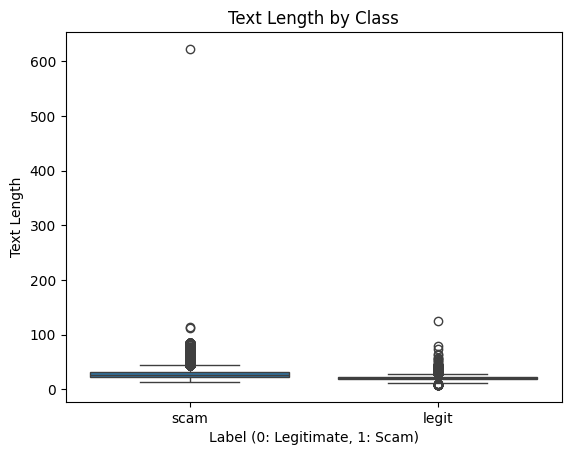

In [10]:
# add a column for text length
datasets_df["url_length"] = datasets_df["url"].apply(len)

# plot the distribution of text lengths
sns.histplot(datasets_df["url_length"], bins=50)
plt.title("Distribution of Text Lengths")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

# compare text lengths for scam vs. legitimate links
sns.boxplot(x="label", y="url_length", data=datasets_df)
plt.title("Text Length by Class")
plt.xlabel("Label (0: Legitimate, 1: Scam)")
plt.ylabel("Text Length")
plt.show()

Unique domains: 65170
Top TLDs: tld
com       34117
io        10692
xyz        5337
net        5153
app        4701
org        4336
dev        3922
top        1845
online     1564
site       1511
Name: count, dtype: int64


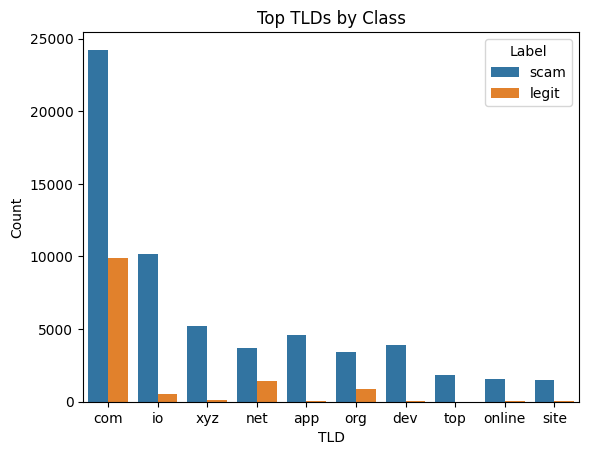

In [11]:
# extract domain and TLD
datasets_df["domain"] = datasets_df["url"].apply(lambda x: tldextract.extract(x).domain)
datasets_df["tld"] = datasets_df["url"].apply(lambda x: tldextract.extract(x).suffix)

# count unique domains and TLDs
print("Unique domains:", datasets_df["domain"].nunique())
print("Top TLDs:", datasets_df["tld"].value_counts().head(10))

# compare TLDs for scam vs. legitimate links
sns.countplot(x="tld", hue="label", data=datasets_df, order=datasets_df["tld"].value_counts().iloc[:10].index)
plt.title("Top TLDs by Class")
plt.xlabel("TLD")
plt.ylabel("Count")
plt.legend(title="Label", loc="upper right")
plt.show()

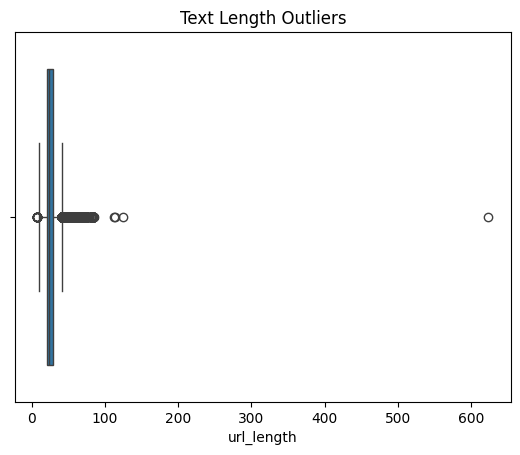

In [12]:
# boxplot for text length
sns.boxplot(x=datasets_df["url_length"])
plt.title("Text Length Outliers")
plt.show()

## preprocessing

In [13]:
# function to process url
def procees_url(url):
    """Extracts features from a URL."""

    TECHNICAL_WORDS = {"www", "http", "https"}

    SCAM_KEYWORDS = [
    "free", "giveaway", "bonus", "earn", "profit", "double", "investment",
    "claim", "win", "lottery", "rich", "money", "wallet", "support",
    "verification", "login", "secure", "account", "recovery"
]

    # Convert to lowercase
    url = url.lower()

    # Extract domain, subdomain, and suffix
    extracted = tldextract.extract(url)
    # domain = extracted.domain
    subdomain = extracted.subdomain
    tld = extracted.suffix

    # tokenisation (split URL into words based on delimiters)
    tokens = re.split(r"[-._~:/?#\[\]@!$&'()*+,;=]+", url)
    # remove only technical words
    filtered_tokens = [t for t in tokens if t and t not in TECHNICAL_WORDS and t != tld]
    filtered_tokens = " ".join(filtered_tokens)

    # Count URL length and number of special characters
    url_length = len(url)
    special_char_count = len(re.findall(r'[.-_/]', url))

    # Common suspicious keywords
    keyword_count = sum(1 for token in tokens if token in SCAM_KEYWORDS)

    return {
        'subdomain': subdomain,
        'special_char_count': special_char_count,
        'keyword_count': keyword_count,
        "tokenized_tokens": filtered_tokens
    }

def detect_typosquatting(url, legitimate_domains, threshold=2):
    # extract domain from URL
    parsed_url = urlparse(url)
    domain = parsed_url.netloc

    # check similarity with legitimate domains
    min_distance = float("inf")
    for legit_domain in legitimate_domains:
        dist = levenshtein_distance(domain, legit_domain)
        if dist < min_distance:
            min_distance = dist

    # flag as typosquatting if the minimum distance is below the threshold
    return int(min_distance <= threshold)

def get_domain_age(url):
    try:
        # fetch domain registration details
        domain_info = whois.whois(url)

        # extract creation date
        creation_date = domain_info.creation_date
        if isinstance(creation_date, list):
            creation_date = creation_date[0]

        # calculate domain age in days
        if creation_date:
            domain_age = (datetime.now() - creation_date).days
        else:
            domain_age = None
    except Exception as e:
        # handle errors (e.g., invalid domain or WHOIS lookup failure)
        domain_age = None

    # return -1 if domain age cannot be determined
    return domain_age if domain_age is not None else -1

In [14]:
# process the url
proceesed_df = pd.DataFrame([procees_url(url) for url in datasets_df["url"]])

In [15]:
# fetch legitimate domains
legitimate_domains = datasets_df[datasets_df["label_no"] == 0]

# detect typosquatting
proceesed_df["is_typosquatting"] = datasets_df["url"].apply(detect_typosquatting, legitimate_domains=legitimate_domains)

# fetch domain age
proceesed_df["domain_age"] = datasets_df["url"].apply(get_domain_age)

set(proceesed_df["domain_age"])

{-1}

In [16]:
datasets_df[['subdomain','special_char_count','keyword_count', 'tokenized_tokens']] = proceesed_df[['subdomain','special_char_count','keyword_count', 'tokenized_tokens']]
datasets_df

,url,label,label_no,url_length,domain,tld,subdomain,special_char_count,keyword_count,tokenized_tokens
0,https://arbitrum-claim.net,scam,1,26,arbitrum-claim,net,,4,1,arbitrum claim
1,https://allocate-dym.network,scam,1,28,allocate-dym,network,,4,0,allocate dym
2,https://rionegro.com.ar,legit,0,23,rionegro,com.ar,,5,0,rionegro com ar
3,https://net-layerzero.com,scam,1,25,net-layerzero,com,,4,0,net layerzero
4,https://leugss.top,scam,1,18,leugss,top,,4,0,leugss
...,...,...,...,...,...,...,...,...,...,...
99995,https://youversionapi.com,legit,0,25,youversionapi,com,,4,0,youversionapi
99996,https://saintssinnersnft.com,scam,1,28,saintssinnersnft,com,,4,0,saintssinnersnft
99997,https://convexfinence.com,scam,1,25,convexfinence,com,,4,0,convexfinence
99998,https://app.velar.co/swap,legit,0,25,velar,co,app,6,0,app velar swap


## feature engineering

In [17]:
label_map = {0: "legit", 1: "scam"}
label_map

{0: 'legit', 1: 'scam'}

#### tf-idf
- unigrams, bigrams, and trigrams

In [18]:
# TF-IDF vectorization
# vectorizer = TfidfVectorizer(max_features=5000)
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)
X_tfidf = vectorizer.fit_transform(datasets_df["tokenized_tokens"]).toarray()

#### nnlm

In [19]:
# using nnlm-50

# load NNLM embeddings (50-dimensional)
embed_50 = hub.load("https://tfhub.dev/google/nnlm-en-dim50/2")

# fetch embeddings of urls
X_embeddings_50 = embed_50(datasets_df["tokenized_tokens"].tolist()).numpy()

X_embeddings_50

array([[ 0.03077845, -0.26711565,  0.01830282, ...,  0.2072107 ,
         0.02002396,  0.11362914],
       [ 0.09021033, -0.11310953, -0.01836494, ..., -0.04607791,
         0.32672518,  0.29600132],
       [ 0.253772  , -0.34026456, -0.12066936, ...,  0.22596209,
         0.09758833,  0.09508254],
       ...,
       [ 0.42437407,  0.17515412,  0.0380774 , ...,  0.06362747,
        -0.03616028,  0.16073953],
       [-0.02407273, -0.12908407,  0.06917294, ...,  0.07424268,
         0.23407027,  0.1536021 ],
       [ 0.20205095,  0.2557025 ,  0.00315733, ...,  0.2201928 ,
        -0.03696417, -0.01444183]], dtype=float32)

In [20]:
# using nnlm-128

# load NNLM embeddings (128-dimensional)
embed_128 = hub.load("https://tfhub.dev/google/nnlm-en-dim50/2")

# fetch embeddings of urls
X_embeddings_128 = embed_128(datasets_df["tokenized_tokens"].tolist()).numpy()

X_embeddings_128

array([[ 0.03077845, -0.26711565,  0.01830282, ...,  0.2072107 ,
         0.02002396,  0.11362914],
       [ 0.09021033, -0.11310953, -0.01836494, ..., -0.04607791,
         0.32672518,  0.29600132],
       [ 0.253772  , -0.34026456, -0.12066936, ...,  0.22596209,
         0.09758833,  0.09508254],
       ...,
       [ 0.42437407,  0.17515412,  0.0380774 , ...,  0.06362747,
        -0.03616028,  0.16073953],
       [-0.02407273, -0.12908407,  0.06917294, ...,  0.07424268,
         0.23407027,  0.1536021 ],
       [ 0.20205095,  0.2557025 ,  0.00315733, ...,  0.2201928 ,
        -0.03696417, -0.01444183]], dtype=float32)

#### feature engineering continued...

In [21]:
# Combine with URL-specific features
X_combined = np.hstack((X_tfidf, datasets_df[["url_length", "special_char_count", "keyword_count"]].values))

In [22]:
# split the data
X_train, X_test, y_train, y_test = train_test_split(X_combined, datasets_df["label"], test_size=0.2, random_state=42)

print("number of tweets in training dataset: ", X_train.shape[0])
print("number of tweets in testing dataset: ", X_test.shape[0])

number of tweets in training dataset:  80000
number of tweets in testing dataset:  20000


## modelling

In [23]:
def get_confusion_metric(model, X_train, y_train, X_test, y_test):
    # train the model on training data
    model.fit(X_train, y_train)

    # evaluate the model
    y_pred = model.predict(X_test)

    # calculate the performance metrics
    accuracy = accuracy_score(y_test, y_pred)

    confusion = confusion_matrix(y_test, y_pred)


    return accuracy, confusion

def train_model(model_name, model):
    accuracy, confusion = get_confusion_metric(model, X_train, y_train, X_test, y_test)
    print("Model Name:", model_name)
    print("Accuracy: ", accuracy)
    print("Confusion Matrix: ", confusion)
    disp = ConfusionMatrixDisplay(confusion, display_labels = label_map.keys())
    disp.plot()
    plt.show()

In [24]:
lr_model = LogisticRegression(max_iter = 300, multi_class = "multinomial")

# rfc_model = RandomForestClassifier(class_weight="balanced", random_state=42)

In [ ]:
# using logisitics regression
train_model("Logistic Regression", lr_model)

# using random forest classifier
# train_model("Random Forest Classifier", rfc_model)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
